In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from simulation import GridWorldEnv, CreateGrid
from algorithm import AStarAlgorithm
from helper import Metrics, get_grid, get_grid_img, create_show_grid

# Intelligente Robotik 
#### WS 2024/25
Julienne Eder, Lea Achter

---

## Dynamische Erstellung der Grid Worlds

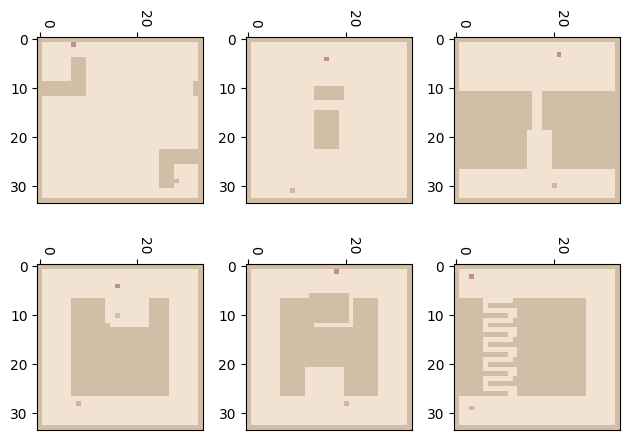

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=3)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

grid_creator = CreateGrid()

star_dict = grid_creator.create_grid('star_grid', 32)
star_data = get_grid_img(star_dict['grid'], (star_dict['agent_x'], star_dict['agent_y']), (star_dict['goal_x'],star_dict['goal_y']))
im = get_grid(star_data, ax=ax1)

simple__dict = grid_creator.create_grid('simple_grid', 32)
simple_data = get_grid_img(simple__dict['grid'], (simple__dict['agent_x'], simple__dict['agent_y']), (simple__dict['goal_x'] ,simple__dict['goal_y']))
im = get_grid(simple_data, ax=ax2)

bottleneck_dict = grid_creator.create_grid('bottleneck_grid', 32)
bottleneck_data = get_grid_img(bottleneck_dict['grid'], (bottleneck_dict['agent_x'], bottleneck_dict['agent_y']), (bottleneck_dict['goal_x'],bottleneck_dict['goal_y']))
im = get_grid(bottleneck_data, ax=ax3)

trap_dict = grid_creator.create_grid('trap_grid', 32)
trap_data = get_grid_img(trap_dict['grid'], (trap_dict['agent_x'], trap_dict['agent_y']), (trap_dict['goal_x'],trap_dict['goal_y']))
im = get_grid(trap_data, ax=ax4)

doubletrap_dict = grid_creator.create_grid('doubletrap_grid', 32)
doubletrap_data = get_grid_img(doubletrap_dict['grid'], (doubletrap_dict['agent_x'], doubletrap_dict['agent_y']), (doubletrap_dict['goal_x'],doubletrap_dict['goal_y']))
im = get_grid(doubletrap_data, ax=ax5)

detour_dict = grid_creator.create_grid('detour_grid', 32)
detour_data = get_grid_img(detour_dict['grid'], (detour_dict['agent_x'], detour_dict['agent_y']), (detour_dict['goal_x'],detour_dict['goal_y']))
im = get_grid(detour_data, ax=ax6)

fig.tight_layout()
plt.show()

In [4]:
# ToDo: Dynamische Griderstellung

## Algorithmen

| |  A*  | Wavefront (BFS)  | MITM (BFS) | Q-Learning| SASAR|
|:------------- |:------------- |:---------------:| -------------:| -------------:|-------------:|
| Speicherkomplexität | O(n)         | O(rows * cols)|O(rows * cols)|O(n_states * action_space)| O(n_states * action_space)| 
| Laufzeitkomplexität | O(n^2 log n)  |O(rows * cols)|O(rows * cols)| O(episodes * max_steps * action_space)| O(episodes * max_steps * action_space)| 
| Echtzeit (E) / Anytime (A)| E   | E | E | A | A | 
| Ausführungszeit (avg_empty_64) | 0.05538 ± 0.04596 | tbd | 0.00395 ± 0.00090 | Cell 3 |  Cell| 
| Steps bis Konvergenz (avg_empty_64)| 1752.20000 ± 983.96553   | tbd | 2306.20000 ± 297.81095 | - | - | 
| Durchschnittliche Pfadlänge (avg_empty_64)| 65.40000 ± 7.88923 | tbd          |63.20000 ± 6.91086| - | -| 


\
\
Meet-in-the-middle (MITM) \
breadth-first search (BFS)

> RQ1: ....

### A* Algorithmus

ToDo: Beschreibung

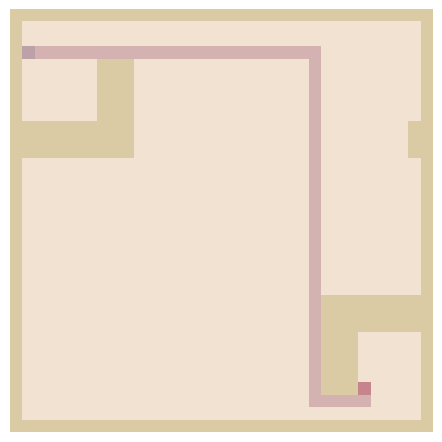

In [82]:
# show example grid

data = create_show_grid(algorithm='A-star', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [74]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df



Metriken des A*-Algorithmus mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00021 ± 0.00019,15.80000 ± 2.31517,100.20000 ± 70.41704
1,star_grid,0.00192 ± 0.00005,31.00000 ± 1.41421,844.00000 ± 294.15642
2,simple_grid,0.00029 ± 0.00015,17.00000 ± 2.09762,1423.00000 ± 81.47883
3,bottleneck_grid,0.00013 ± 0.00004,18.60000 ± 1.85472,1679.20000 ± 58.85372
4,trap_grid,0.00020 ± 0.00008,21.60000 ± 1.20000,1921.00000 ± 81.45919
5,doubletrap_grid,0.00019 ± 0.00004,22.20000 ± 2.48193,2208.00000 ± 72.66636
6,detour_grid,0.00007 ± 0.00001,18.60000 ± 1.35647,2395.00000 ± 37.21828
7,all,0.00043 ± 0.00062,20.68571 ± 5.07527,1510.05714 ± 757.96061


In [75]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df



Metriken des A*-Algorithmus mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00257 ± 0.00233,32.80000 ± 4.53431,662.00000 ± 186.29439
1,star_grid,0.02071 ± 0.00249,58.80000 ± 1.93907,3046.40000 ± 977.80931
2,simple_grid,0.00359 ± 0.00134,37.60000 ± 1.95959,5264.40000 ± 321.98174
3,bottleneck_grid,0.00131 ± 0.00079,35.80000 ± 5.30660,6059.60000 ± 228.73356
4,trap_grid,0.00151 ± 0.00063,40.20000 ± 4.44522,6925.40000 ± 219.20547
5,doubletrap_grid,0.00215 ± 0.00165,42.20000 ± 3.65513,7814.00000 ± 260.99195
6,detour_grid,0.00426 ± 0.00038,73.80000 ± 1.16619,9106.60000 ± 472.10956
7,all,0.00516 ± 0.00661,45.88571 ± 14.26438,5554.05714 ± 2716.46801


In [62]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='A-star', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des A*-Algorithmus mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df



Metriken für den A*-Algorithmus mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.05538 ± 0.04596,65.40000 ± 7.88923,1752.20000 ± 983.96553
1,star_grid,0.24883 ± 0.03986,112.00000 ± 2.75681,11064.60000 ± 3509.44443
2,simple_grid,0.03345 ± 0.02739,70.00000 ± 12.50600,18702.00000 ± 947.08796
3,bottleneck_grid,0.01412 ± 0.00874,70.80000 ± 10.20588,21200.40000 ± 800.43403
4,trap_grid,0.01618 ± 0.00600,84.20000 ± 5.74108,24354.60000 ± 825.02766
5,doubletrap_grid,0.02962 ± 0.01358,91.20000 ± 6.82349,27806.20000 ± 1311.19661
6,detour_grid,0.04759 ± 0.01018,144.60000 ± 6.11882,33191.80000 ± 1562.63475
7,all,0.06360 ± 0.08128,91.17143 ± 27.54683,19724.54286 ± 9921.15262


### Wavefront

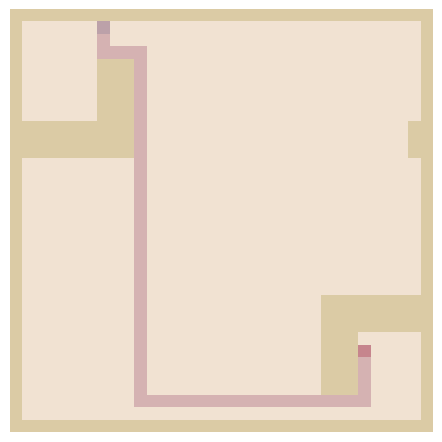

In [83]:
# show example grid

data = create_show_grid(algorithm='Wavefront', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [93]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df



Metriken des Wavefront mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



/home/lea/miniconda3/envs/robotics_project/lib/python3.13/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00030 ± 0.00006,17.00000 ± 2.82843,inf ± nan
1,star_grid,0.00036 ± 0.00007,31.20000 ± 1.83303,inf ± nan
2,simple_grid,0.00025 ± 0.00004,16.80000 ± 1.72047,inf ± nan
3,bottleneck_grid,0.00015 ± 0.00002,18.00000 ± 2.68328,inf ± nan
4,trap_grid,0.00019 ± 0.00001,21.60000 ± 1.62481,inf ± nan
5,doubletrap_grid,0.00017 ± 0.00002,20.20000 ± 3.05941,inf ± nan
6,detour_grid,0.00013 ± 0.00001,18.60000 ± 1.35647,inf ± nan
7,all,0.00022 ± 0.00009,20.48571 ± 5.16788,inf ± nan


In [94]:
# get metrics 
size_grid = 32
num_runs = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df



Metriken des Wavefront mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



/home/lea/miniconda3/envs/robotics_project/lib/python3.13/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00123 ± 0.00018,36.00000 ± 4.04969,inf ± nan
1,star_grid,0.00124 ± 0.00003,56.80000 ± 1.32665,inf ± nan
2,simple_grid,0.00103 ± 0.00015,33.80000 ± 4.70744,inf ± nan
3,bottleneck_grid,0.00061 ± 0.00008,34.80000 ± 2.63818,inf ± nan
4,trap_grid,0.00077 ± 0.00011,41.60000 ± 4.84149,inf ± nan
5,doubletrap_grid,0.00090 ± 0.00012,43.20000 ± 4.87442,inf ± nan
6,detour_grid,0.00088 ± 0.00003,75.20000 ± 2.31517,inf ± nan
7,all,0.00095 ± 0.00024,45.91429 ± 14.49408,inf ± nan


In [95]:
# get metrics 
size_grid = 64
num_runs = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='Wavefront', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des Wavefront mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df



Metriken des Wavefront mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



/home/lea/miniconda3/envs/robotics_project/lib/python3.13/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00498 ± 0.00085,68.00000 ± 11.40175,inf ± nan
1,star_grid,0.00638 ± 0.00107,114.60000 ± 6.46838,inf ± nan
2,simple_grid,0.00523 ± 0.00063,71.00000 ± 8.98888,inf ± nan
3,bottleneck_grid,0.00261 ± 0.00015,70.20000 ± 5.84466,inf ± nan
4,trap_grid,0.00434 ± 0.00022,87.00000 ± 4.56070,inf ± nan
5,doubletrap_grid,0.00424 ± 0.00041,87.40000 ± 3.87814,inf ± nan
6,detour_grid,0.00344 ± 0.00007,146.80000 ± 3.86782,inf ± nan
7,all,0.00446 ± 0.00129,92.14286 ± 27.74799,inf ± nan


### Meet-in-the-Middle

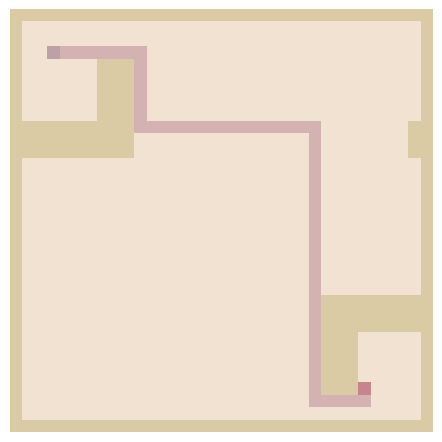

In [92]:
# show example grid

data = create_show_grid(algorithm='MITM', grid='star_grid')
fig, ax = plt.subplots()
im = get_grid(data, ax=ax)
fig.tight_layout()
plt.axis('off')
plt.show()

In [89]:
# get metrics 
size_grid = 16
num_runs = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runs} zufälligen Initializierungen des Grids\n")
df



Metriken des MITM mit einer Gridgröße von 16 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00024 ± 0.00007,16.80000 ± 1.72047,129.20000 ± 26.96961
1,star_grid,0.00032 ± 0.00008,31.20000 ± 0.74833,168.00000 ± 0.00000
2,simple_grid,0.00020 ± 0.00004,15.80000 ± 2.13542,115.60000 ± 29.60135
3,bottleneck_grid,0.00016 ± 0.00000,18.40000 ± 1.95959,99.60000 ± 5.81722
4,trap_grid,0.00020 ± 0.00002,22.40000 ± 1.95959,123.40000 ± 18.03996
5,doubletrap_grid,0.00021 ± 0.00002,22.60000 ± 2.24499,130.60000 ± 15.10761
6,detour_grid,0.00012 ± 0.00001,19.20000 ± 0.74833,67.20000 ± 1.60000
7,all,0.00021 ± 0.00007,20.91429 ± 5.13460,119.08571 ± 33.64467


In [90]:
# get metrics 
size_grid = 32
num_runns = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runs=num_runs)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runns} zufälligen Initializierungen des Grids\n")
df

Hindernis konnte nicht platziert werden


Metriken des MITM mit einer Gridgröße von 32 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00100 ± 0.00035,33.80000 ± 6.79412,561.80000 ± 187.30766
1,star_grid,0.00108 ± 0.00002,57.80000 ± 2.48193,708.00000 ± 0.00000
2,simple_grid,0.00090 ± 0.00019,33.60000 ± 3.38231,538.80000 ± 79.40378
3,bottleneck_grid,0.00064 ± 0.00002,37.60000 ± 4.49889,418.20000 ± 14.42775
4,trap_grid,0.00081 ± 0.00010,44.40000 ± 4.58694,531.40000 ± 65.15397
5,doubletrap_grid,0.00089 ± 0.00019,41.40000 ± 4.40908,492.60000 ± 60.85918
6,detour_grid,0.00087 ± 0.00012,75.60000 ± 1.95959,529.00000 ± 0.00000
7,all,0.00088 ± 0.00022,46.31429 ± 14.83196,539.97143 ± 116.81719


In [91]:
# get metrics 
size_grid = 64
num_runns = 5

metrics = Metrics()
df = metrics.get_metrics(algorithm='MITM', size_grid=size_grid, num_runns=num_runns)

print(f"\n\nMetriken des MITM mit einer Gridgröße von {size_grid} und {num_runns} zufälligen Initializierungen des Grids\n")
df

Hindernis konnte nicht platziert werden
Hindernis konnte nicht platziert werden


Metriken des MITM mit einer Gridgröße von 64 und 5 zufälligen Initializierungen des Grids



,benchmark,avg_time (sec),avg_path_length,avg_steps_to_converge
0,empty,0.00395 ± 0.00090,63.20000 ± 6.91086,2306.20000 ± 297.81095
1,star_grid,0.00612 ± 0.00071,110.60000 ± 4.45421,2987.80000 ± 7.70454
2,simple_grid,0.00447 ± 0.00072,68.00000 ± 8.14862,2410.00000 ± 318.75069
3,bottleneck_grid,0.00279 ± 0.00027,68.20000 ± 6.96850,1626.60000 ± 111.86349
4,trap_grid,0.00352 ± 0.00040,83.20000 ± 6.46220,2033.80000 ± 188.43821
5,doubletrap_grid,0.00371 ± 0.00042,86.60000 ± 7.11618,2071.00000 ± 196.97309
6,detour_grid,0.00355 ± 0.00028,149.00000 ± 3.28634,1999.00000 ± 0.00000
7,all,0.00402 ± 0.00113,89.82857 ± 29.09638,2204.91429 ± 441.82475


### Q-Learning

In [14]:
# get metrics
metrics = Metrics()
df  = metrics.get_rl_metrics(algorithm='qlearning')
df

  0%|          | 0/500 [00:00<?, ?it/s]

/home/lea/Dokumente/WS24_25/Robotik_projekt/helper/metrics.py:115: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measurements = pd.concat([measurements, row], ignore_index=True)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,benchmark,train_epoch,avg_time_train (sec),mean_reward,std_reward
0,empty,500,6.235379,74.0,0.0
1,empty,1000,5.706507,74.0,0.0
2,empty,10000,14.359127,62.0,0.0
3,star_grid,500,19.129438,-2048.0,0.0
4,star_grid,1000,39.748888,-2048.0,0.0
5,star_grid,10000,26.501712,44.0,0.0
6,simple_grid,500,6.262034,61.0,0.0
7,simple_grid,1000,6.813970,69.0,0.0
8,simple_grid,10000,14.248051,70.0,0.0
9,bottleneck_grid,500,35.727365,-2048.0,0.0


### SASAR

In [15]:
# get metrics
metrics = Metrics()
df  = metrics.get_rl_metrics(algorithm='sasar')
df

  0%|          | 0/500 [00:00<?, ?it/s]

/home/lea/Dokumente/WS24_25/Robotik_projekt/helper/metrics.py:115: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  measurements = pd.concat([measurements, row], ignore_index=True)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,benchmark,train_epoch,avg_time_train (sec),mean_reward,std_reward
0,empty,500,6.465819,55.0,0.0
1,empty,1000,6.996316,-2048.0,0.0
2,empty,10000,15.439563,60.0,0.0
3,star_grid,500,18.828745,-2048.0,0.0
4,star_grid,1000,37.342807,-2048.0,0.0
5,star_grid,10000,376.046881,-2048.0,0.0
6,simple_grid,500,8.248941,-2048.0,0.0
7,simple_grid,1000,9.558864,65.0,0.0
8,simple_grid,10000,23.846312,-2048.0,0.0
9,bottleneck_grid,500,26.764113,-10240.0,0.0
